In [6]:
import torch
import networkx as nx

In [3]:
num_entities = 10
num_relations = 3
num_timestamps = 2
num_facts = 50

# Random integer generation for each column
subjects = torch.randint(0, num_entities, (num_facts, 1))
objects = torch.randint(0, num_entities, (num_facts, 1))
relations = torch.randint(0, num_relations, (num_facts, 1))
timestamps = torch.randint(0, num_timestamps, (num_facts, 1))

# Concatenate columns into a single tensor
facts = torch.cat([subjects, objects, relations, timestamps], dim=1)

# Drop duplicates
facts = torch.unique(facts, dim=0)

print(f"Number of unique facts: {facts.size(0)}")

Number of unique facts: 47


In [ ]:
edges = torch.unique(facts[:, [0, 2]], dim=0)
edges_np = edges.numpy()

In [ ]:
G = nx.from_edgelist(edges_np, create_using=nx.DiGraph())


# Visualization

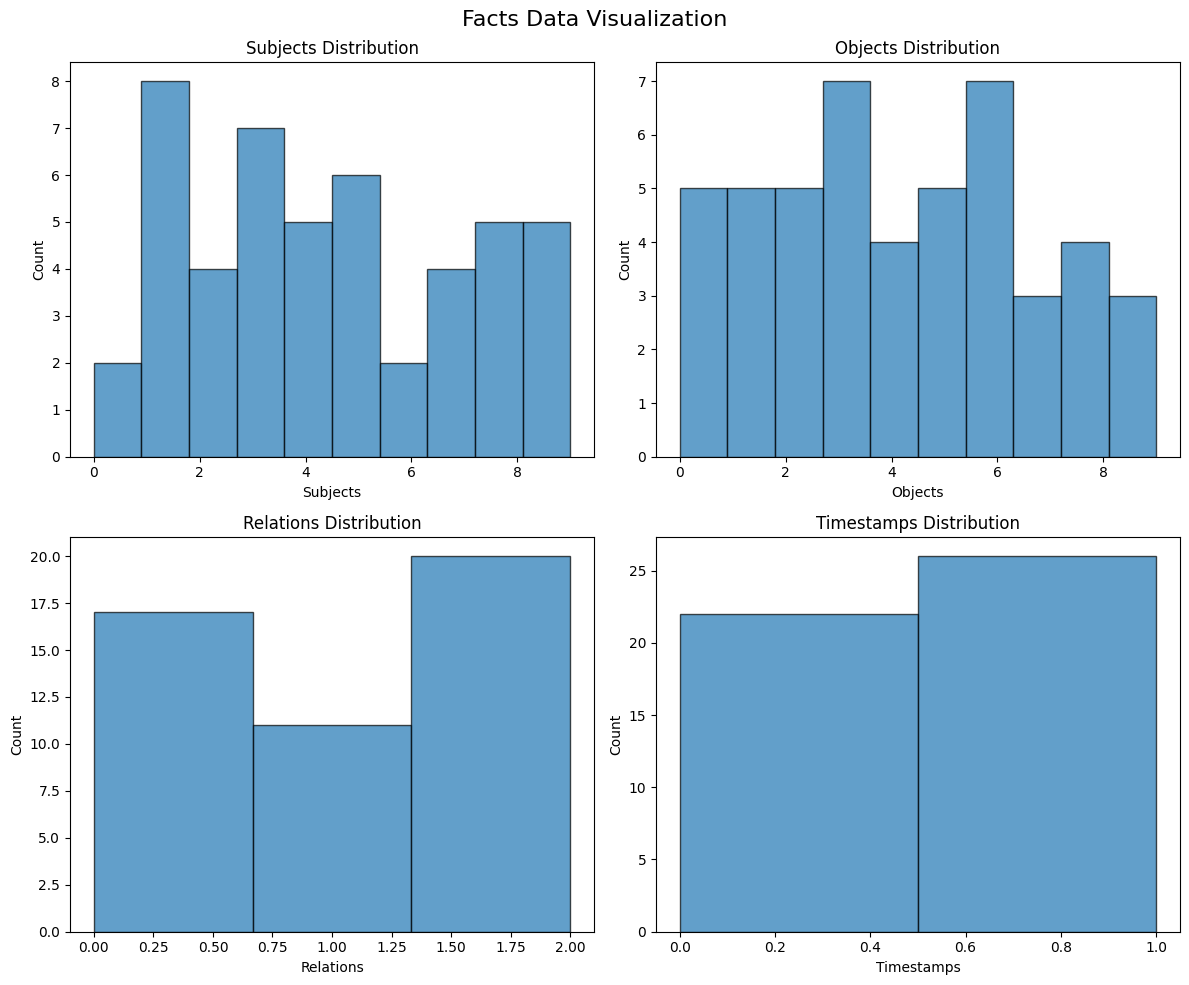

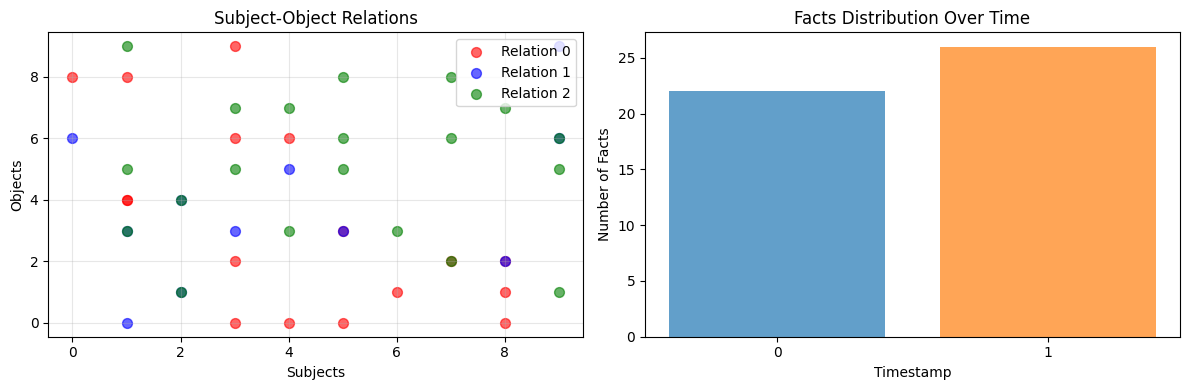


Sample facts (first 10):
Subject | Object | Relation | Timestamp
-----------------------------------
    0   |    6   |     1    |      0
    0   |    8   |     0    |      1
    1   |    0   |     1    |      1
    1   |    3   |     1    |      1
    1   |    3   |     2    |      1
    1   |    4   |     0    |      0
    1   |    4   |     0    |      1
    1   |    5   |     2    |      1
    1   |    8   |     0    |      1
    1   |    9   |     2    |      1


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy for visualization
facts_np = facts.numpy()

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Facts Data Visualization', fontsize=16)

# 1. Distribution of each column
for i, (ax, label) in enumerate(zip(axes.flat, ['Subjects', 'Objects', 'Relations', 'Timestamps'])):
    ax.hist(facts_np[:, i], bins=max(2, len(np.unique(facts_np[:, i]))), alpha=0.7, edgecolor='black')
    ax.set_title(f'{label} Distribution')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Additional compact visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Relation network (subject-object pairs colored by relation)
colors = ['red', 'blue', 'green'][:num_relations]
for rel in range(num_relations):
    mask = facts_np[:, 2] == rel
    if mask.any():
        ax1.scatter(facts_np[mask, 0], facts_np[mask, 1], 
                   c=colors[rel], alpha=0.6, label=f'Relation {rel}', s=50)

ax1.set_xlabel('Subjects')
ax1.set_ylabel('Objects')
ax1.set_title('Subject-Object Relations')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Facts over time
for t in range(num_timestamps):
    mask = facts_np[:, 3] == t
    count = mask.sum()
    ax2.bar(t, count, alpha=0.7, label=f'Time {t}')

ax2.set_xlabel('Timestamp')
ax2.set_ylabel('Number of Facts')
ax2.set_title('Facts Distribution Over Time')
ax2.set_xticks(range(num_timestamps))

plt.tight_layout()
plt.show()

# Print sample facts
print(f"\nSample facts (first 10):")
print("Subject | Object | Relation | Timestamp")
print("-" * 35)
for i in range(min(10, facts.size(0))):
    print(f"   {facts_np[i, 0]:2d}   |   {facts_np[i, 1]:2d}   |    {facts_np[i, 2]:2d}    |     {facts_np[i, 3]:2d}")

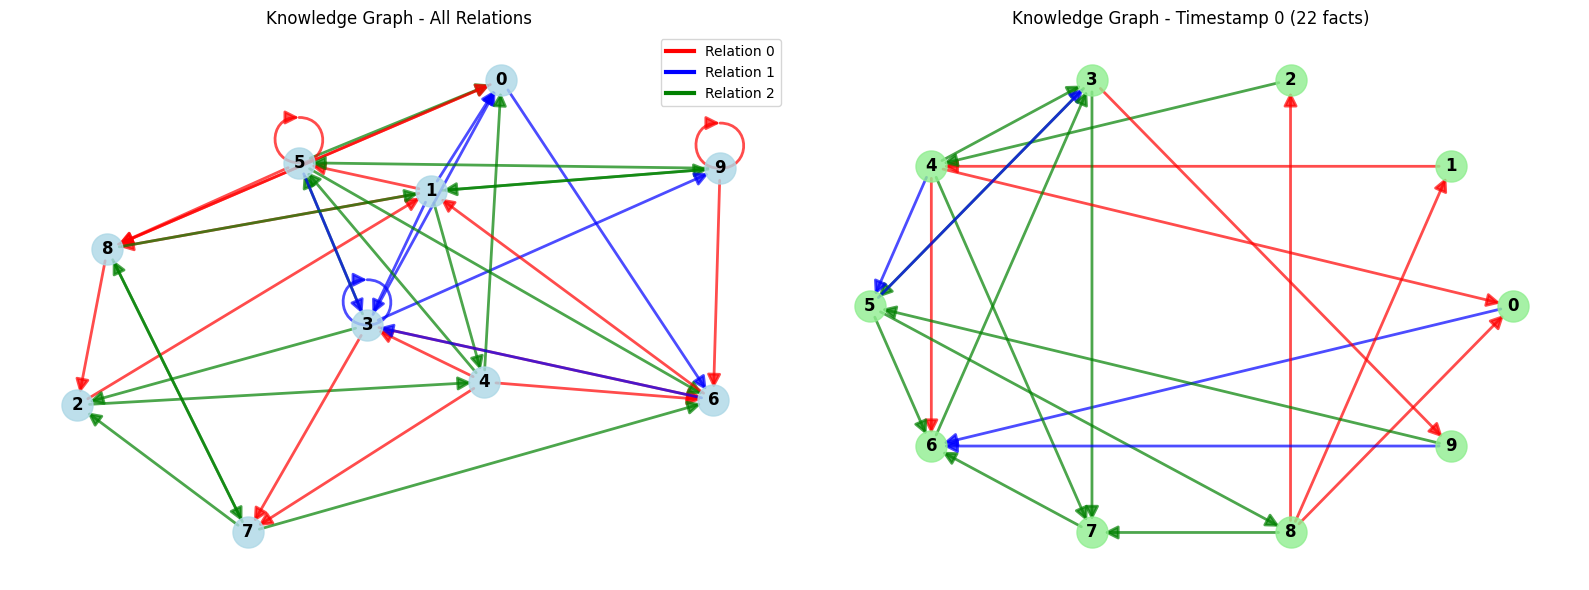


Graph Statistics:
Nodes: 10
Edges: 40
Average degree: 8.00

Facts by relation:
Relation 0: 17 facts
Relation 1: 11 facts
Relation 2: 20 facts


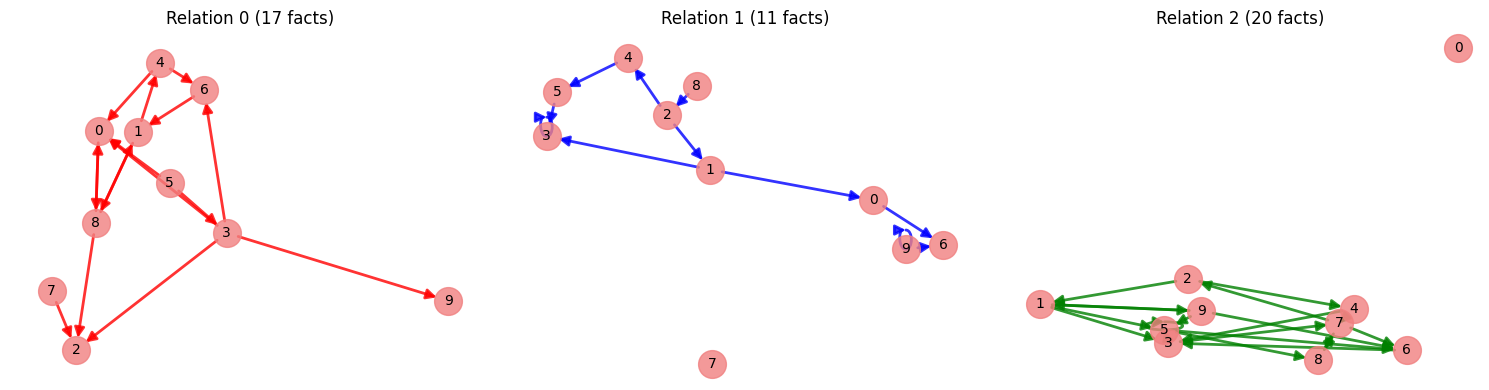

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert to numpy
facts_np = facts.numpy()

# Create graph visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: All relations in one graph with different edge colors
G = nx.DiGraph()

# Add all entities as nodes
for i in range(num_entities):
    G.add_node(i)

# Add edges with attributes
relation_colors = ['red', 'blue', 'green']
edge_colors = []

for fact in facts_np:
    subj, obj, rel, time = fact
    G.add_edge(subj, obj, relation=rel, timestamp=time)
    edge_colors.append(relation_colors[rel])

# Draw first graph
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color='lightblue', 
                       node_size=500, alpha=0.8)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color=edge_colors, 
                       arrows=True, arrowsize=20, alpha=0.7, width=2)

axes[0].set_title('Knowledge Graph - All Relations')
axes[0].axis('off')

# Create legend for relations
for i, color in enumerate(relation_colors[:num_relations]):
    axes[0].plot([], [], color=color, linewidth=3, label=f'Relation {i}')
axes[0].legend()

# Graph 2: Temporal graph (facts at different timestamps)
G_time = nx.DiGraph()

# Add nodes
for i in range(num_entities):
    G_time.add_node(i)

# Only show facts from timestamp 0 for clarity
time_facts = facts_np[facts_np[:, 3] == 0]
time_edge_colors = []

for fact in time_facts:
    subj, obj, rel, time = fact
    G_time.add_edge(subj, obj, relation=rel)
    time_edge_colors.append(relation_colors[rel])

# Draw second graph
pos2 = nx.circular_layout(G_time)
nx.draw_networkx_nodes(G_time, pos2, ax=axes[1], node_color='lightgreen', 
                       node_size=500, alpha=0.8)
nx.draw_networkx_labels(G_time, pos2, ax=axes[1], font_size=12, font_weight='bold')
nx.draw_networkx_edges(G_time, pos2, ax=axes[1], edge_color=time_edge_colors, 
                       arrows=True, arrowsize=20, alpha=0.7, width=2)

axes[1].set_title(f'Knowledge Graph - Timestamp 0 ({len(time_facts)} facts)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print graph statistics
print(f"\nGraph Statistics:")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# Print facts by relation
print(f"\nFacts by relation:")
for rel in range(num_relations):
    count = sum(1 for fact in facts_np if fact[2] == rel)
    print(f"Relation {rel}: {count} facts")

# Alternative: Separate subgraphs for each relation
fig, axes = plt.subplots(1, num_relations, figsize=(5*num_relations, 4))
if num_relations == 1:
    axes = [axes]

for rel in range(num_relations):
    G_rel = nx.DiGraph()
    
    # Add nodes and edges for this relation only
    rel_facts = facts_np[facts_np[:, 2] == rel]
    
    for i in range(num_entities):
        G_rel.add_node(i)
    
    for fact in rel_facts:
        subj, obj, _, _ = fact
        G_rel.add_edge(subj, obj)
    
    # Draw subgraph
    pos = nx.spring_layout(G_rel, seed=42)
    nx.draw_networkx_nodes(G_rel, pos, ax=axes[rel], node_color='lightcoral', 
                          node_size=400, alpha=0.8)
    nx.draw_networkx_labels(G_rel, pos, ax=axes[rel], font_size=10)
    nx.draw_networkx_edges(G_rel, pos, ax=axes[rel], edge_color=relation_colors[rel], 
                          arrows=True, arrowsize=15, alpha=0.8, width=2)
    
    axes[rel].set_title(f'Relation {rel} ({len(rel_facts)} facts)')
    axes[rel].axis('off')

plt.tight_layout()
plt.show()

# Temporal KG Partition

In [11]:
import time

In [28]:
def avg_time(facts_matrix, num_trials: int = 10) -> float:

    times = []
    for i in range(num_trials):
        tic = time.time()
        for fact_idx, fact in enumerate(facts_matrix):
            continue

        times.append(time.time() - tic)
    
    return np.mean(times) * 1000


In [53]:
avg_time(facts)

0.15480518341064453

In [54]:
avg_time(facts.numpy())

0.0066280364990234375

In [17]:
import pandas as pd

facts_pd = pd.DataFrame(facts_np)

In [52]:
tic = time.time()
for fact_idx, fact in enumerate(facts_np):
    continue

(time.time() - tic)*1000

0.080108642578125

In [ ]:
import networkx as nx

def partition_graph_by_avg_degree(G: nx.DiGraph, num_partitions: int):
    nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
    partitions = [[] for _ in range(num_partitions)]
    avg_degrees = [0] * num_partitions

    for node in nodes:
        best_partition = min(
            range(num_partitions),
            key=lambda i: abs((avg_degrees[i] * len(partitions[i]) + G.degree(node)) / (len(partitions[i]) + 1) -
                              sum(avg_degrees) / num_partitions)
        )
        partitions[best_partition].append(node)
        avg_degrees[best_partition] = (
            avg_degrees[best_partition] * (len(partitions[best_partition]) - 1) + G.degree(node)
        ) / len(partitions[best_partition])
    return partitions


In [56]:
import torch
import numpy as np
from collections import defaultdict
import random

def random_walk_partition(facts_index: np.ndarray, num_partitions: int, walk_length: int = 3, num_walks_per_seed: int = 5) -> list[np.ndarray]:
    """Partition using random walks from seed nodes"""
    
    # Build adjacency structure
    adj_list = defaultdict(list)
    entity_facts = defaultdict(list)  # Track which facts involve each entity
    
    for fact_idx, fact in enumerate(facts_index):
        subj, rel, obj, time = fact[0], fact[1], fact[2], fact[3]
        adj_list[subj].append((obj, rel, time, fact_idx))
        adj_list[obj].append((subj, rel, time, fact_idx))  # Make undirected
        entity_facts[subj].append(fact_idx)
        entity_facts[obj].append(fact_idx)
    
    # Get all unique entities
    all_entities = list(adj_list.keys())
    
    # Select seed nodes for each partition
    seeds = random.sample(all_entities, min(num_partitions, len(all_entities)))
    
    # Perform random walks from each seed
    partition_entities = [set() for _ in range(num_partitions)]
    partition_facts = [set() for _ in range(num_partitions)]
    
    for partition_id, seed in enumerate(seeds):
        for _ in range(num_walks_per_seed):
            walk_entities, walk_facts = random_walk(adj_list, entity_facts, seed, walk_length)
            partition_entities[partition_id].update(walk_entities)
            partition_facts[partition_id].update(walk_facts)
    
    # Assign remaining entities to nearest partition
    assigned_entities = set().union(*partition_entities)
    remaining_entities = set(all_entities) - assigned_entities
    
    for entity in remaining_entities:
        # Assign to random partition or use some heuristic
        partition_id = hash(entity) % num_partitions
        partition_entities[partition_id].add(entity)
        partition_facts[partition_id].update(entity_facts[entity])
    
    # Convert to tensors
    result_partitions = []
    for fact_set in partition_facts:
        if fact_set:
            fact_indices = list(fact_set)
            result_partitions.append(facts_index[fact_indices])
    
    return result_partitions

def random_walk(adj_list, entity_facts, start_node, walk_length):
    """Perform a single random walk"""
    current = start_node
    visited_entities = {current}
    visited_facts = set(entity_facts[current])
    
    for _ in range(walk_length):
        if current not in adj_list or not adj_list[current]:
            break
            
        # Choose random neighbor
        neighbors = adj_list[current]
        next_node, rel, time, fact_idx = random.choice(neighbors)
        
        visited_entities.add(next_node)
        visited_facts.add(fact_idx)
        current = next_node
    
    return visited_entities, visited_facts

In [59]:
parititons = random_walk_partition(facts_np, num_partitions=100)

In [60]:
parititons

[array([[0, 6, 1, 0],
        [1, 9, 2, 1],
        [2, 4, 2, 0],
        [4, 6, 0, 0],
        [4, 7, 2, 0],
        [5, 0, 0, 1],
        [5, 3, 0, 1],
        [5, 3, 1, 0],
        [5, 5, 2, 1],
        [5, 6, 2, 0],
        [5, 8, 2, 0],
        [7, 6, 2, 0],
        [9, 1, 2, 1],
        [9, 6, 1, 0]]),
 array([[3, 0, 0, 1],
        [3, 2, 0, 1],
        [3, 3, 1, 1],
        [3, 5, 2, 0],
        [3, 6, 0, 1],
        [3, 7, 2, 0],
        [3, 9, 0, 0],
        [4, 0, 0, 0],
        [6, 1, 0, 1],
        [6, 3, 2, 0]]),
 array([[1, 3, 1, 1],
        [1, 3, 2, 1],
        [1, 4, 0, 1],
        [1, 5, 2, 1],
        [2, 4, 2, 0],
        [3, 7, 2, 0],
        [4, 0, 0, 0],
        [4, 3, 2, 0],
        [4, 5, 1, 0],
        [4, 6, 0, 0],
        [4, 7, 2, 0],
        [5, 3, 1, 0]]),
 array([[0, 6, 1, 0],
        [0, 8, 0, 1],
        [1, 0, 1, 1],
        [1, 4, 0, 0],
        [1, 4, 0, 1],
        [1, 8, 0, 1],
        [3, 0, 0, 1],
        [3, 2, 0, 1],
        [3, 6, 0, 1],
    